In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
df_player = pd.read_csv('data/world_tva.csv')
df_player.head()

,number,name,position,age,nationality,team,value
0,1,Lamine Yamal,Right Winger,18,Spain,FC Barcelona,200.0
1,2,Erling Haaland,Centre-Forward,25,Norway,Manchester City,200.0
2,3,Kylian Mbappé,Centre-Forward,27,France,Real Madrid,200.0
3,4,Jude Bellingham,Attacking Midfield,22,England,Real Madrid,160.0
4,5,Vinicius Junior,Left Winger,25,Brazil,Real Madrid,150.0


In [3]:
df_player = df_player.rename(columns={'value': 'VALUE_EURO'})
df_player['VALUE_KRW'] = df_player['VALUE_EURO'] * 13 # 대략 1유로 = 1300

# 컬럼명을 전부 대문자로 변환 (코딩하기 편하게)
df_player.columns = [col.upper() for col in df_player.columns]

cols = ['NUMBER', 'NAME', 'POSITION', 'AGE', 'NATIONALITY', 'TEAM', 'VALUE_EURO', 'VALUE_KRW']
df_player = df_player[cols]

df_player.head()

,NUMBER,NAME,POSITION,AGE,NATIONALITY,TEAM,VALUE_EURO,VALUE_KRW
0,1,Lamine Yamal,Right Winger,18,Spain,FC Barcelona,200.0,2600.0
1,2,Erling Haaland,Centre-Forward,25,Norway,Manchester City,200.0,2600.0
2,3,Kylian Mbappé,Centre-Forward,27,France,Real Madrid,200.0,2600.0
3,4,Jude Bellingham,Attacking Midfield,22,England,Real Madrid,160.0,2080.0
4,5,Vinicius Junior,Left Winger,25,Brazil,Real Madrid,150.0,1950.0


In [4]:
# 1. 간단하게 일단 몸값 상위 top_50
top_50 = df_player.nlargest(50,'VALUE_KRW')
print(top_50)


    NUMBER                   NAME            POSITION  AGE  NATIONALITY  \
0        1           Lamine Yamal        Right Winger   18        Spain   
1        2         Erling Haaland      Centre-Forward   25       Norway   
2        3          Kylian Mbappé      Centre-Forward   27       France   
3        4        Jude Bellingham  Attacking Midfield   22      England   
4        5        Vinicius Junior         Left Winger   25       Brazil   
5        6                  Pedri    Central Midfield   23        Spain   
6        7          Jamal Musiala  Attacking Midfield   22      Germany   
7        8          Michael Olise        Right Winger   24       France   
8        9            Bukayo Saka        Right Winger   24      England   
9       10            Cole Palmer  Attacking Midfield   23      England   
10      11      Federico Valverde    Central Midfield   27      Uruguay   
11      12            Declan Rice    Central Midfield   27      England   
12      13         Alexan

C:\Users\ojy05\AppData\Local\Temp\ipykernel_24032\2998121771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ojy05\AppData\Local\Temp\ipykernel_24032\2998121771.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


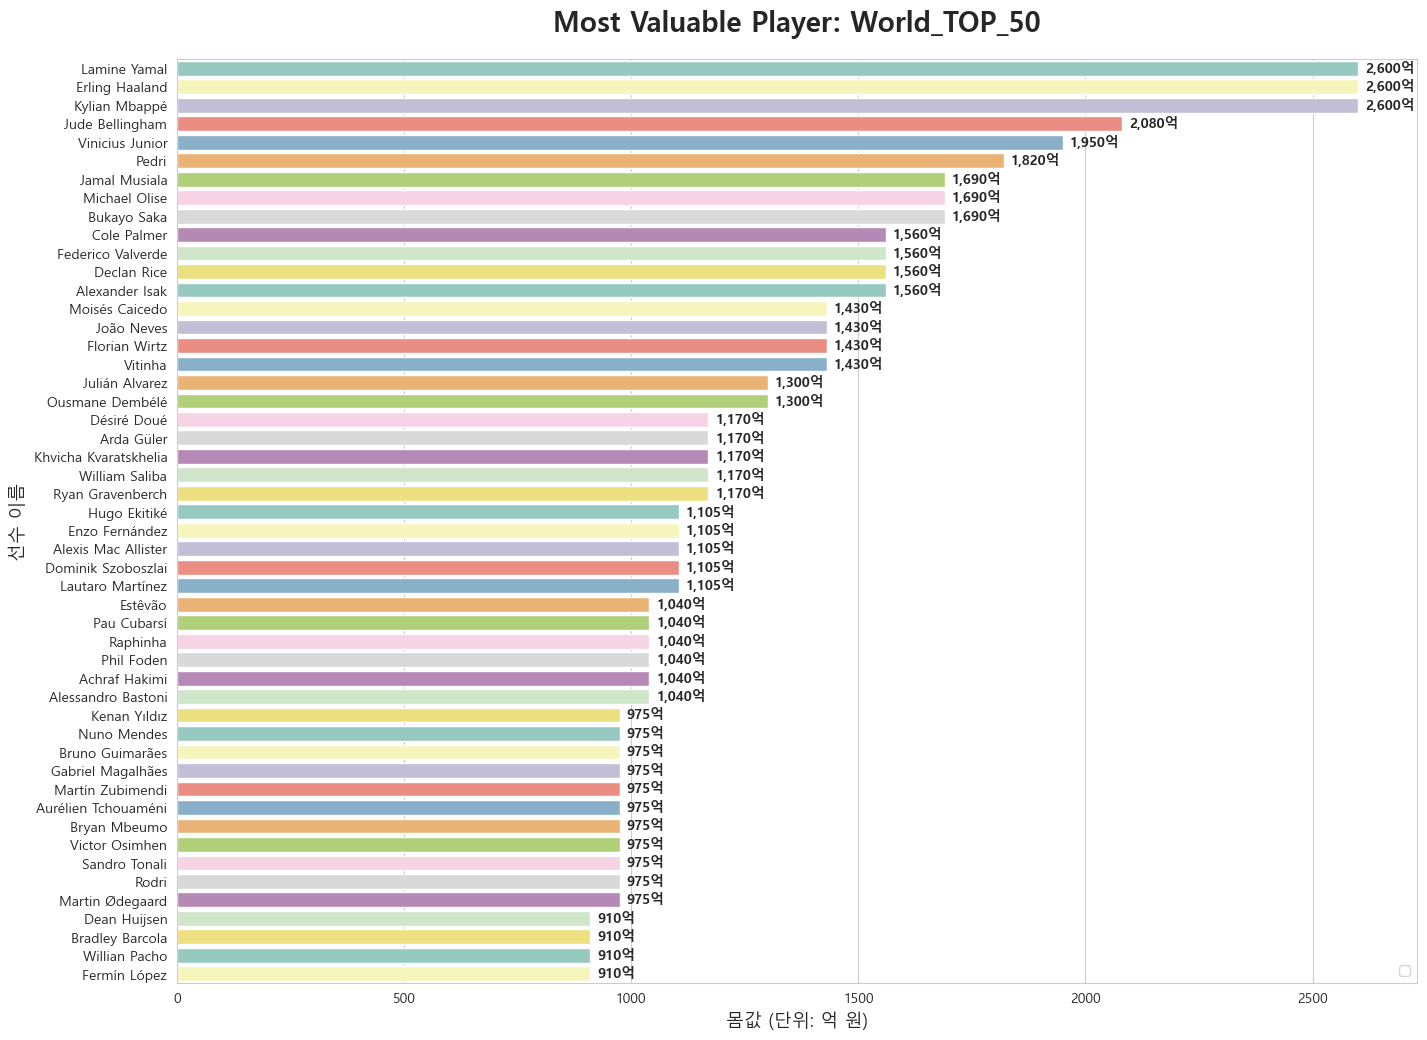

In [5]:
plt.figure(figsize=(16,12))
sns.set_style('whitegrid')
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
ax = sns.barplot(
  data=top_50,
  x='VALUE_KRW',
  y='NAME',
  palette='Set3'
)

for p in ax.patches:
  width = p.get_width()
  if width > 0: # 0보다 큰 경우만 표시
    ax.annotate(f'{int(width):,}억',
                (width, p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5,0), textcoords='offset points',
                fontsize=10, fontweight='bold'
                )

plt.title("Most Valuable Player: World_TOP_50", fontsize=20, pad=20,fontweight='bold')
plt.xlabel('몸값 (단위: 억 원)', fontsize=13)
plt.ylabel('선수 이름',fontsize=13)

plt.legend()

plt.show()

C:\Users\ojy05\AppData\Local\Temp\ipykernel_24032\2890375801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='TEAM', data=top_50, ax=axes[0], order=top_50['TEAM'].value_counts().index, palette='rocket')


Text(0.5, 1.0, 'Top 50 주요 국적 비중')

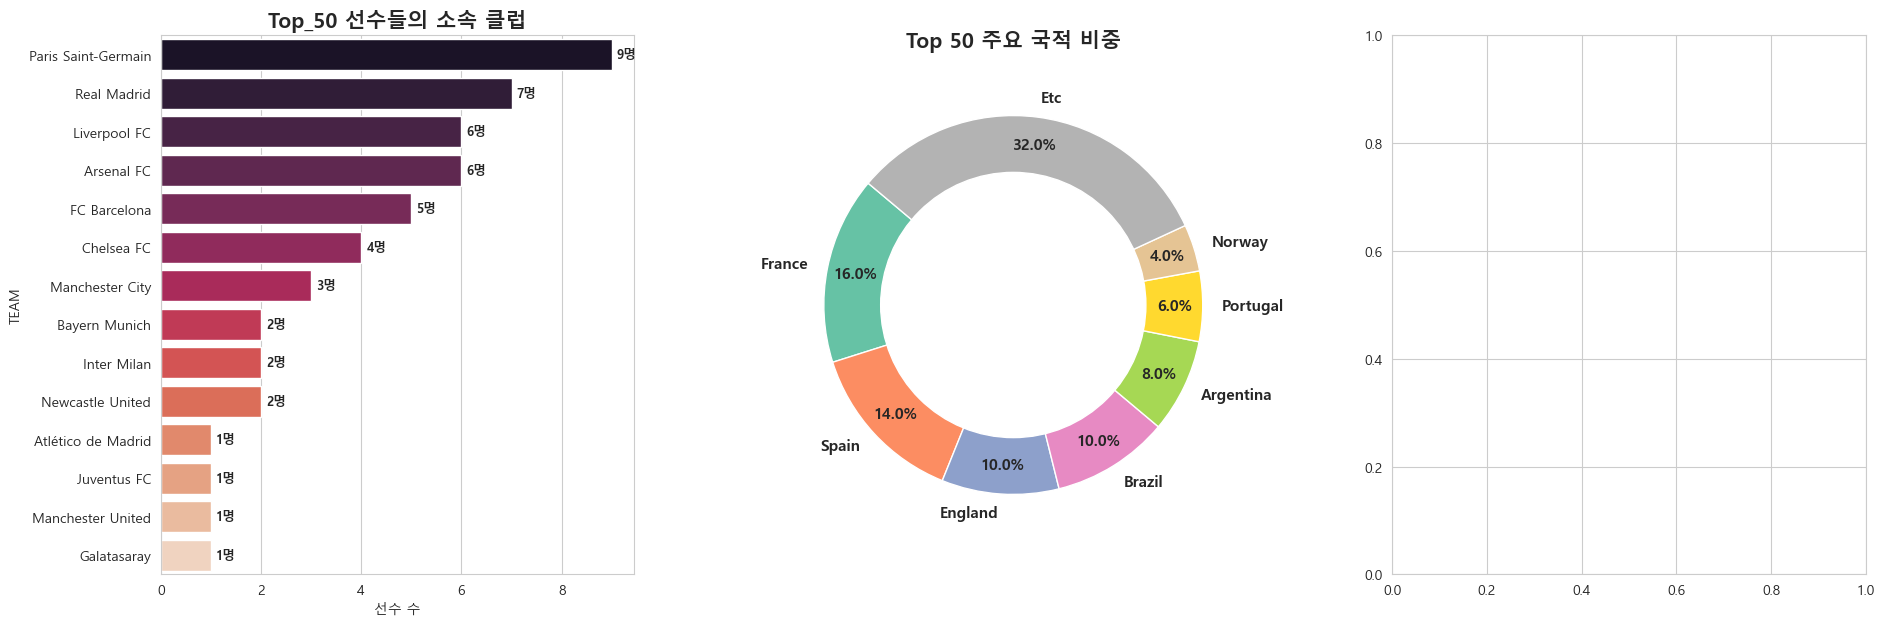

In [6]:
# Top 50의 소속 클럽, 국적, 포지션 분포 (3개의 그래프로)
# 한 번에 3개의 그래프를 그리기 위한 설정 
fig, axes = plt.subplots(1, 3, figsize=(22,7))
plt.subplots_adjust(wspace=0.3) # 그래프 사이의 간격

# 1. 소속 클럽 분포
sns.countplot(y='TEAM', data=top_50, ax=axes[0], order=top_50['TEAM'].value_counts().index, palette='rocket')
axes[0].set_title('Top_50 선수들의 소속 클럽', fontsize=15, fontweight='bold')
axes[0].set_xlabel('선수 수')

# 막대 옆 숫자 표시
for p in axes[0].patches:
  axes[0].annotate(f'{int(p.get_width())}명',
                   (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
                   va='center', fontsize=9, fontweight='bold')

# 2. 국적
# 상위 7개국만 표시하고 나머지는 'Etc'로 합쳐서 보여주기
nation_counts = top_50['NATIONALITY'].value_counts()
top_nations = nation_counts.head(7)
etc_nations = pd.Series({'Etc': nation_counts.iloc[7:].sum()})
plot_nations = pd.concat([top_nations, etc_nations])

# 중앙에 구멍이 뚫린 도넛 차트
axes[1].pie(plot_nations, labels=plot_nations.index, autopct='%1.1f%%',
            startangle=140, pctdistance=0.85, colors=sns.color_palette('Set2'),
            textprops={'fontsize': 11, 'fontweight': 'bold'})

# 중앙에 흰색 원을 그린 도넛 모양
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Top 50 주요 국적 비중', fontsize=15, fontweight= 'bold', pad=15)
